In [2]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [3]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [4]:
df = pd.read_csv('experiment_metrics_fully_parallel/linear_head_deviation.csv')

In [7]:
df.columns

Index(['val/forces_mae', 'train/forces_mse', '_runtime',
       'val/pct_loss_from_equiv_error', 'val/forces_magnitude_error',
       'train/loss', 'train/step', '_timestamp',
       'train/forces_magnitude_error', 'train/lr',
       'val/forces_cosine_similarity', 'val/grad_norm_ratio_equiv_over_mean',
       'val/loss', 'train/forces_cosine_similarity', 'val/equiv_error',
       'val/epoch', 'train/grad_norm', 'val/energy_forces_within_threshold',
       'val/force_head_weight_normalized_variance', 'val/energy_rmse',
       'train/energy_mae', 'val/energy_mae', 'val/force_head_weight_variance',
       'val/equiv_grad_norm', 'train/energy_forces_within_threshold',
       'val/energy_mse', 'val/forces_rmse', 'train/energy_rmse',
       'val/total_mse', 'train/energy_mse', 'val/mean_pred_grad_norm',
       'train/forces_rmse', '_step', 'train/forces_mae', 'train/epoch',
       'val/forces_mse', 'val/mean_pred_error'],
      dtype='object')

<Axes: xlabel='_step', ylabel='val/force_head_weight_normalized_variance'>

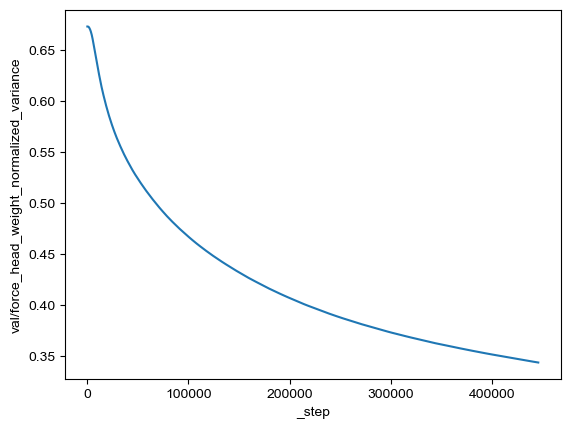

In [10]:
sns.lineplot(data=df, x='_step', y='val/force_head_weight_normalized_variance')

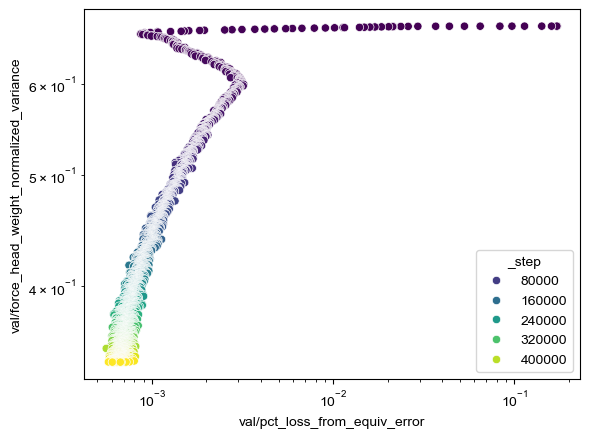

In [ ]:
sns.scatterplot(data=df, x='val/pct_loss_from_equiv_error', y='val/force_head_weight_normalized_variance', hue = '_step', palette='viridis')
plt.xscale('log')
plt.yscale('log')



{'pearson': {'correlation': 0.857479469163761, 'p-value': 0.0}, 'spearman': {'correlation': 0.9367162817748298, 'p-value': 0.0}}


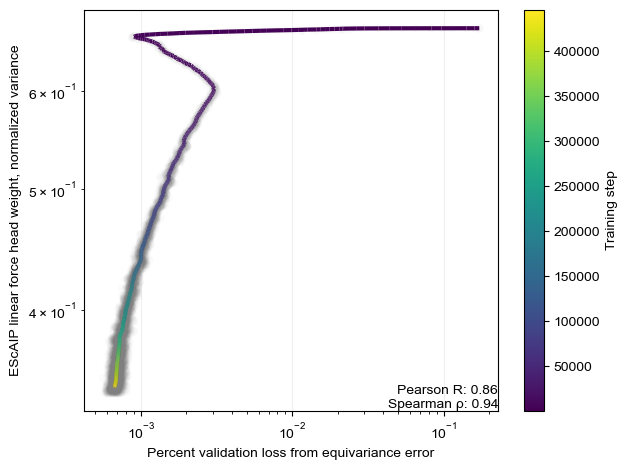

In [17]:
mdf = df
mdf['_log step'] = np.log(mdf['_step'])

def get_correlation_stats(col1, col2, log_scale=False):
    from scipy.stats import pearsonr, spearmanr
    filt_mdf = mdf[~np.isnan(mdf[col1]) & ~np.isnan(mdf[col2])]
    if log_scale:
        filt_mdf = filt_mdf[filt_mdf[col1] > 0]
        filt_mdf = filt_mdf[filt_mdf[col2] > 0]
        filt_mdf[col1] = np.log(filt_mdf[col1])
        filt_mdf[col2] = np.log(filt_mdf[col2])
    corr_pearson, p_pearson = pearsonr(filt_mdf[col1], filt_mdf[col2])
    corr_spearman, p_spearman = spearmanr(filt_mdf[col1], filt_mdf[col2])
    return {
        'pearson': {
            'correlation': corr_pearson,
            'p-value': p_pearson
        },
        'spearman': {
            'correlation': corr_spearman,
            'p-value': p_spearman
        }
    }

def variable_span_ema(data: pd.Series, span_scale_factor: int = 1000) -> pd.Series:
    """
    Calculates an EMA with a span that increases with the index value (timestep).

    Args:
        data (pd.Series): The input data to smooth. Must have a numeric index (e.g., timesteps).
        span_scale_factor (int): Controls how quickly the span grows. A larger value
                                 means the span grows slower, resulting in less smoothing.
                                 The span at a given timestep `x` is roughly `x / span_scale_factor`.

    Returns:
        pd.Series: The smoothed data with the same index as the input.
    """
    if data.empty:
        return data

    # Get index and values for faster iteration
    index = data.index.to_numpy()
    values = data.to_numpy()
    
    # Initialize the output array and the first EMA value
    ema_values = np.zeros_like(values)
    ema_values[0] = values[0] 

    # Iterate from the second point onwards
    for i in range(1, len(values)):
        current_step = index[i]
        
        # 1. Calculate the variable span. Ensure it's at least 1.
        span = max(1.0, current_step / span_scale_factor)
        
        # 2. Convert span to alpha
        alpha = 2.0 / (span + 1.0)
        
        # 3. Apply the EMA formula
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
        
    return pd.Series(ema_values, index=data.index)

x_col = 'val/pct_loss_from_equiv_error'
y_col = 'val/force_head_weight_normalized_variance'

gn_df = mdf[[x_col, '_step', y_col]].dropna().copy()

# mdf[f'{x_col}_ema'] = mdf[x_col].ewm(span=100, adjust=False).mean()
# x_col = f'{x_col}_ema'

corr_stats = get_correlation_stats(x_col, y_col, log_scale=True)
print(corr_stats)

viridis_cmap = plt.get_cmap('viridis', mdf['_step'].nunique())

plot_df = mdf[[x_col, '_step', y_col]].dropna()

smoothed_gn_df = plot_df.set_index('_step').apply(variable_span_ema)
smoothed_gn_df['_step'] = smoothed_gn_df.index

fig, ax = plt.subplots()
sns.scatterplot(
    data=plot_df,
    x=x_col,
    y=y_col,
    # hue = '_step',
    # palette = 'viridis',
    linewidth = 0,
    alpha = 0.03,
    color = 'gray',
    # alpha = 0.7,
    legend = False,
    ax = ax
)

# sns.lineplot(
#     data=smoothed_gn_df,
#     x=x_col,
#     y=y_col,
#     errorbar = None,
#     sort = False,
#     color = 'black',
# )
from matplotlib.collections import LineCollection
x = smoothed_gn_df[x_col].values
y = smoothed_gn_df[y_col].values
steps = smoothed_gn_df['_step'].values

# Create segments: a list of (x, y) pairs
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 3. Create the LineCollection object
norm = plt.Normalize(steps.min(), steps.max())
lc = LineCollection(segments, cmap='viridis', norm=norm)

# Set the color of each segment based on the step value
lc.set_array(steps)
lc.set_linewidth(3)

# 4. Add the LineCollection to the axes
ax.add_collection(lc)

# 5. Add a colorbar to explain the line's color
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax)
cbar.set_label('Training step')


plt.xscale('log')
plt.yscale('log')
plt.grid(alpha = 0.2)

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plt.legend(frameon=False, title = 'Training step')

left, right = plt.xlim()
bottom, top = plt.ylim()

plt.xlabel('Percent validation loss from equivariance error')
plt.ylabel('EScAIP linear force head weight, normalized variance')
plt.text( right, bottom, 
         f'Pearson R: {corr_stats["pearson"]["correlation"]:.2f}\nSpearman ρ: {corr_stats["spearman"]["correlation"]:.2f}', 
         ha='right', va='bottom')

plot_name = 'escaip-linear_head_deviation_scatter'

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()